In [77]:
import pandas as pd
import numpy as np
# Data visualization
import seaborn as sns
import matplotlib.pylab as plt
# Machine learning
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

In [78]:
# Database
data = pd.read_csv("E:/data/spotify_songs.csv")
data.head(3)

,track_id,track_name,track_artist,track_popularity,track_album_id,track_album_name,track_album_release_date,playlist_name,playlist_id,playlist_genre,...,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms
0,6f807x0ima9a1j3VPbc7VN,I Don't Care (with Justin Bieber) - Loud Luxur...,Ed Sheeran,66,2oCs0DGTsRO98Gh5ZSl2Cx,I Don't Care (with Justin Bieber) [Loud Luxury...,2019-06-14,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,...,6,-2.634,1,0.0583,0.1020,0.000000,0.0653,0.518,122.036,194754
1,0r7CVbZTWZgbTCYdfa2P31,Memories - Dillon Francis Remix,Maroon 5,67,63rPSO264uRjW1X5E6cWv6,Memories (Dillon Francis Remix),2019-12-13,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,...,11,-4.969,1,0.0373,0.0724,0.004210,0.3570,0.693,99.972,162600
2,1z1Hg7Vb0AhHDiEmnDE79l,All the Time - Don Diablo Remix,Zara Larsson,70,1HoSmj2eLcsrR0vE9gThr4,All the Time (Don Diablo Remix),2019-07-05,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,...,1,-3.432,0,0.0742,0.0794,0.000023,0.1100,0.613,124.008,176616


In [79]:
data.shape

(32833, 23)

# Data preprocessing

In [80]:
data.dropna(inplace=True)
data.isnull().sum(),data.shape, print(f"Number of duplicate rows: {data.duplicated().sum()}")

Number of duplicate rows: 0


(track_id                    0
 track_name                  0
 track_artist                0
 track_popularity            0
 track_album_id              0
 track_album_name            0
 track_album_release_date    0
 playlist_name               0
 playlist_id                 0
 playlist_genre              0
 playlist_subgenre           0
 danceability                0
 energy                      0
 key                         0
 loudness                    0
 mode                        0
 speechiness                 0
 acousticness                0
 instrumentalness            0
 liveness                    0
 valence                     0
 tempo                       0
 duration_ms                 0
 dtype: int64,
 (32828, 23),
 None)

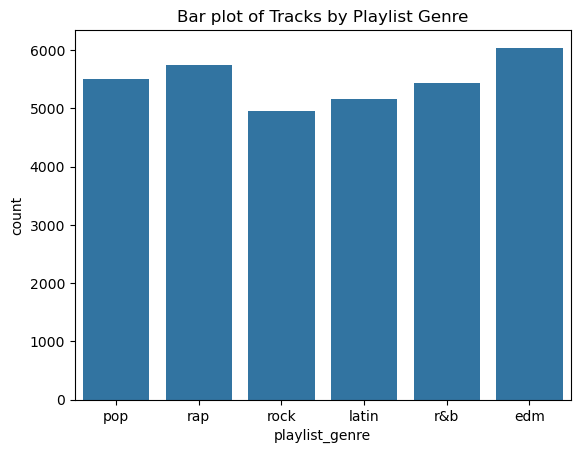

In [81]:
# Count of tracks by playlist genre
sns.countplot(data, x='playlist_genre')
plt.title('Bar plot of Tracks by Playlist Genre')
plt.xticks()
plt.show()

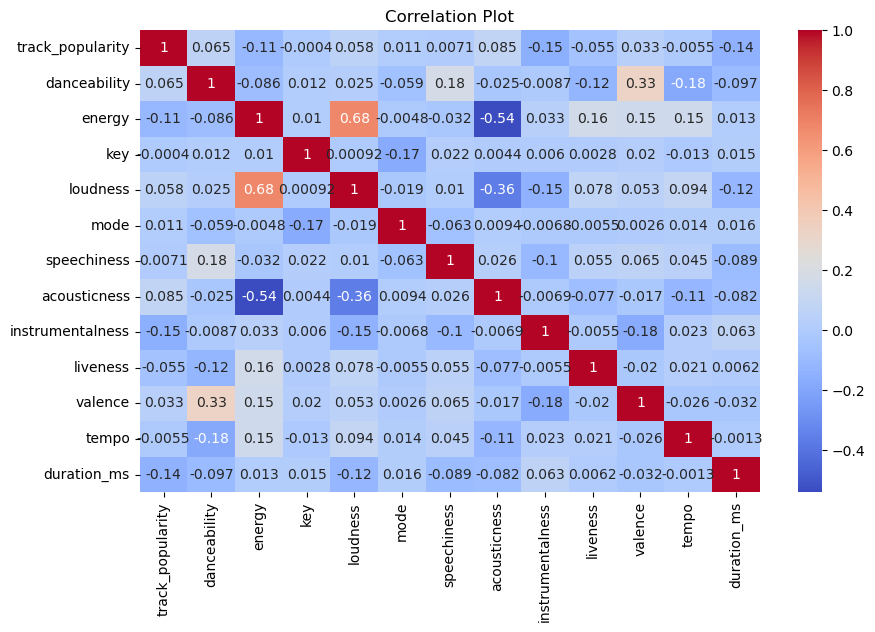

In [82]:
# Selecting only numeric columns
numeric_df = data.select_dtypes(include=['float64', 'int64'])
plt.figure(figsize=(10, 6))
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Plot')
plt.show()

In [83]:
# Select relevant audio features
features = ['danceability', 'energy', 'key', 'loudness', 'mode', 'speechiness', 
            'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo']


In [84]:
data[features]

,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo
0,0.748,0.916,6,-2.634,1,0.0583,0.102000,0.000000,0.0653,0.5180,122.036
1,0.726,0.815,11,-4.969,1,0.0373,0.072400,0.004210,0.3570,0.6930,99.972
2,0.675,0.931,1,-3.432,0,0.0742,0.079400,0.000023,0.1100,0.6130,124.008
3,0.718,0.930,7,-3.778,1,0.1020,0.028700,0.000009,0.2040,0.2770,121.956
4,0.650,0.833,1,-4.672,1,0.0359,0.080300,0.000000,0.0833,0.7250,123.976
...,...,...,...,...,...,...,...,...,...,...,...
32828,0.428,0.922,2,-1.814,1,0.0936,0.076600,0.000000,0.0668,0.2100,128.170
32829,0.522,0.786,0,-4.462,1,0.0420,0.001710,0.004270,0.3750,0.4000,128.041
32830,0.529,0.821,6,-4.899,0,0.0481,0.108000,0.000001,0.1500,0.4360,127.989
32831,0.626,0.888,2,-3.361,1,0.1090,0.007920,0.127000,0.3430,0.3080,128.008


In [85]:
scaler = StandardScaler()
df_scaled = scaler.fit_transform(data[features])
df_scaled = pd.DataFrame(df_scaled, columns=features)

In [86]:
# Split into training (70%) and testing (30%) sets
X_train, X_test = train_test_split(df_scaled, test_size=0.3, random_state=42)
X_train.shape,X_test.shape

((22979, 11), (9849, 11))

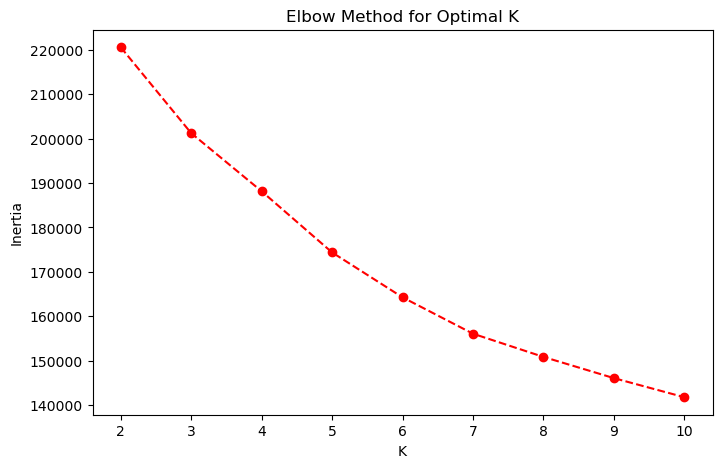

In [87]:
inertia = []
k_range = range(2, 11)  
for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_train)
    inertia.append(kmeans.inertia_)
# Plot Elbow Method graph
plt.figure(figsize=(8,5))
plt.plot(k_range, inertia, marker='o', linestyle='--',color="red")
plt.xlabel("K")
plt.ylabel("Inertia")
plt.title("Elbow Method for Optimal K")
plt.show()
kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)
data['Cluster'] = kmeans.fit_predict(df_scaled)

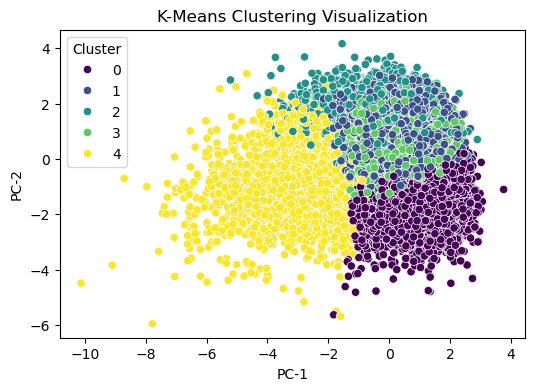

In [88]:
pca = PCA(n_components=2)
df_pca = pca.fit_transform(df_scaled)
data['PCA1'] = df_pca[:, 0]
data['PCA2'] = df_pca[:, 1]

# Scatter plot of clusters
plt.figure(figsize=(6,4))
sns.scatterplot(x=data['PCA1'], y=data['PCA2'], hue=data['Cluster'], palette='viridis')
plt.xlabel("PC-1")
plt.ylabel("PC-2")
plt.title("K-Means Clustering Visualization")
plt.legend(title="Cluster")
plt.show()


In [89]:
from sklearn.metrics import mean_absolute_error, r2_score
def evaluate_knn_model(knn, X_test):
    distances, _ = knn.kneighbors(X_test)
    zero_baseline = np.zeros_like(distances)
    mse = mean_squared_error(zero_baseline, distances)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(zero_baseline, distances)
    r2 = r2_score(zero_baseline, distances)
    print(f"Mean Squared Error (MSE): {mse:.2f}")
    print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
    print(f"Mean Absolute Error (MAE): {mae:.2f}")

print("========== Training Data==============")
evaluate_knn_model(knn, X_train)
print("========== Testing Data==============")
evaluate_knn_model(knn, X_test)


========== Training Data==============
Mean Squared Error (MSE): 1.15
Root Mean Squared Error (RMSE): 1.07
Mean Absolute Error (MAE): 0.88
========== Testing Data==============
Mean Squared Error (MSE): 1.46
Root Mean Squared Error (RMSE): 1.21
Mean Absolute Error (MAE): 1.10


C:\Users\Haider\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but NearestNeighbors was fitted with feature names
  warnings.warn(


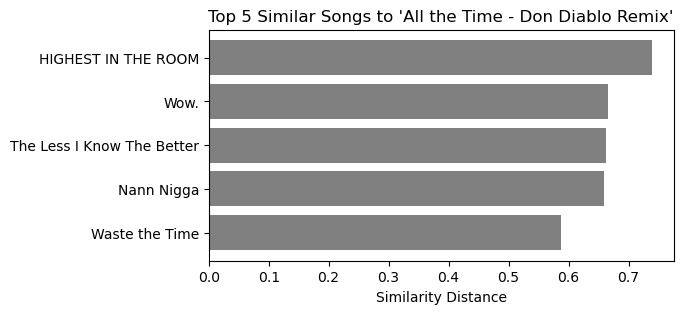

In [91]:
knn = NearestNeighbors(n_neighbors=6, metric='euclidean')
knn.fit(X_train)
def recommend_songs(song_name, data, features, scaler, knn):
    song_idx = data[data['track_name'] == song_name].index[0]
    song_features = df_scaled.iloc[song_idx].values.reshape(1, -1)
    distances, indices = knn.kneighbors(song_features)
    recommended_songs = [data.iloc[idx]['track_name'] for idx in indices[0][1:]]
    plt.figure(figsize=(6, 3))
    plt.barh(recommended_songs[::-1], distances[0][1:][::-1], color='grey')
    plt.xlabel("Similarity Distance")
    plt.title(f"Top 5 Similar Songs to '{song_name}'")
    plt.gca().invert_yaxis()
    plt.show()
# Example usage
recommend_songs("All the Time - Don Diablo Remix", data, X_test, scaler, knn)